<a href="https://colab.research.google.com/github/neuromatch/climate-course-content/blob/main/projects/project-notebooks/Heatwaves_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/neuromatch/climate-course-content/main/projects/project-notebooks/Heatwaves_2024.ipynb" target="_parent"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open in Kaggle"/></a>

# Shanghai heatwaves study

In [24]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import label

In [25]:
# data import
data_sh = xr.open_mfdataset("/home/jovyan/shared-public/poseidon_heatwaves/data/era5_land/Era5_land_*")
# normal data
daily_normal_data =  data_sh.t2m.sel(valid_time=slice("1991","2020"))
monthly_normal_data = daily_normal_data.groupby('valid_time.month').mean().compute()
# monthly_data.resample(valid_time="ME").mean()

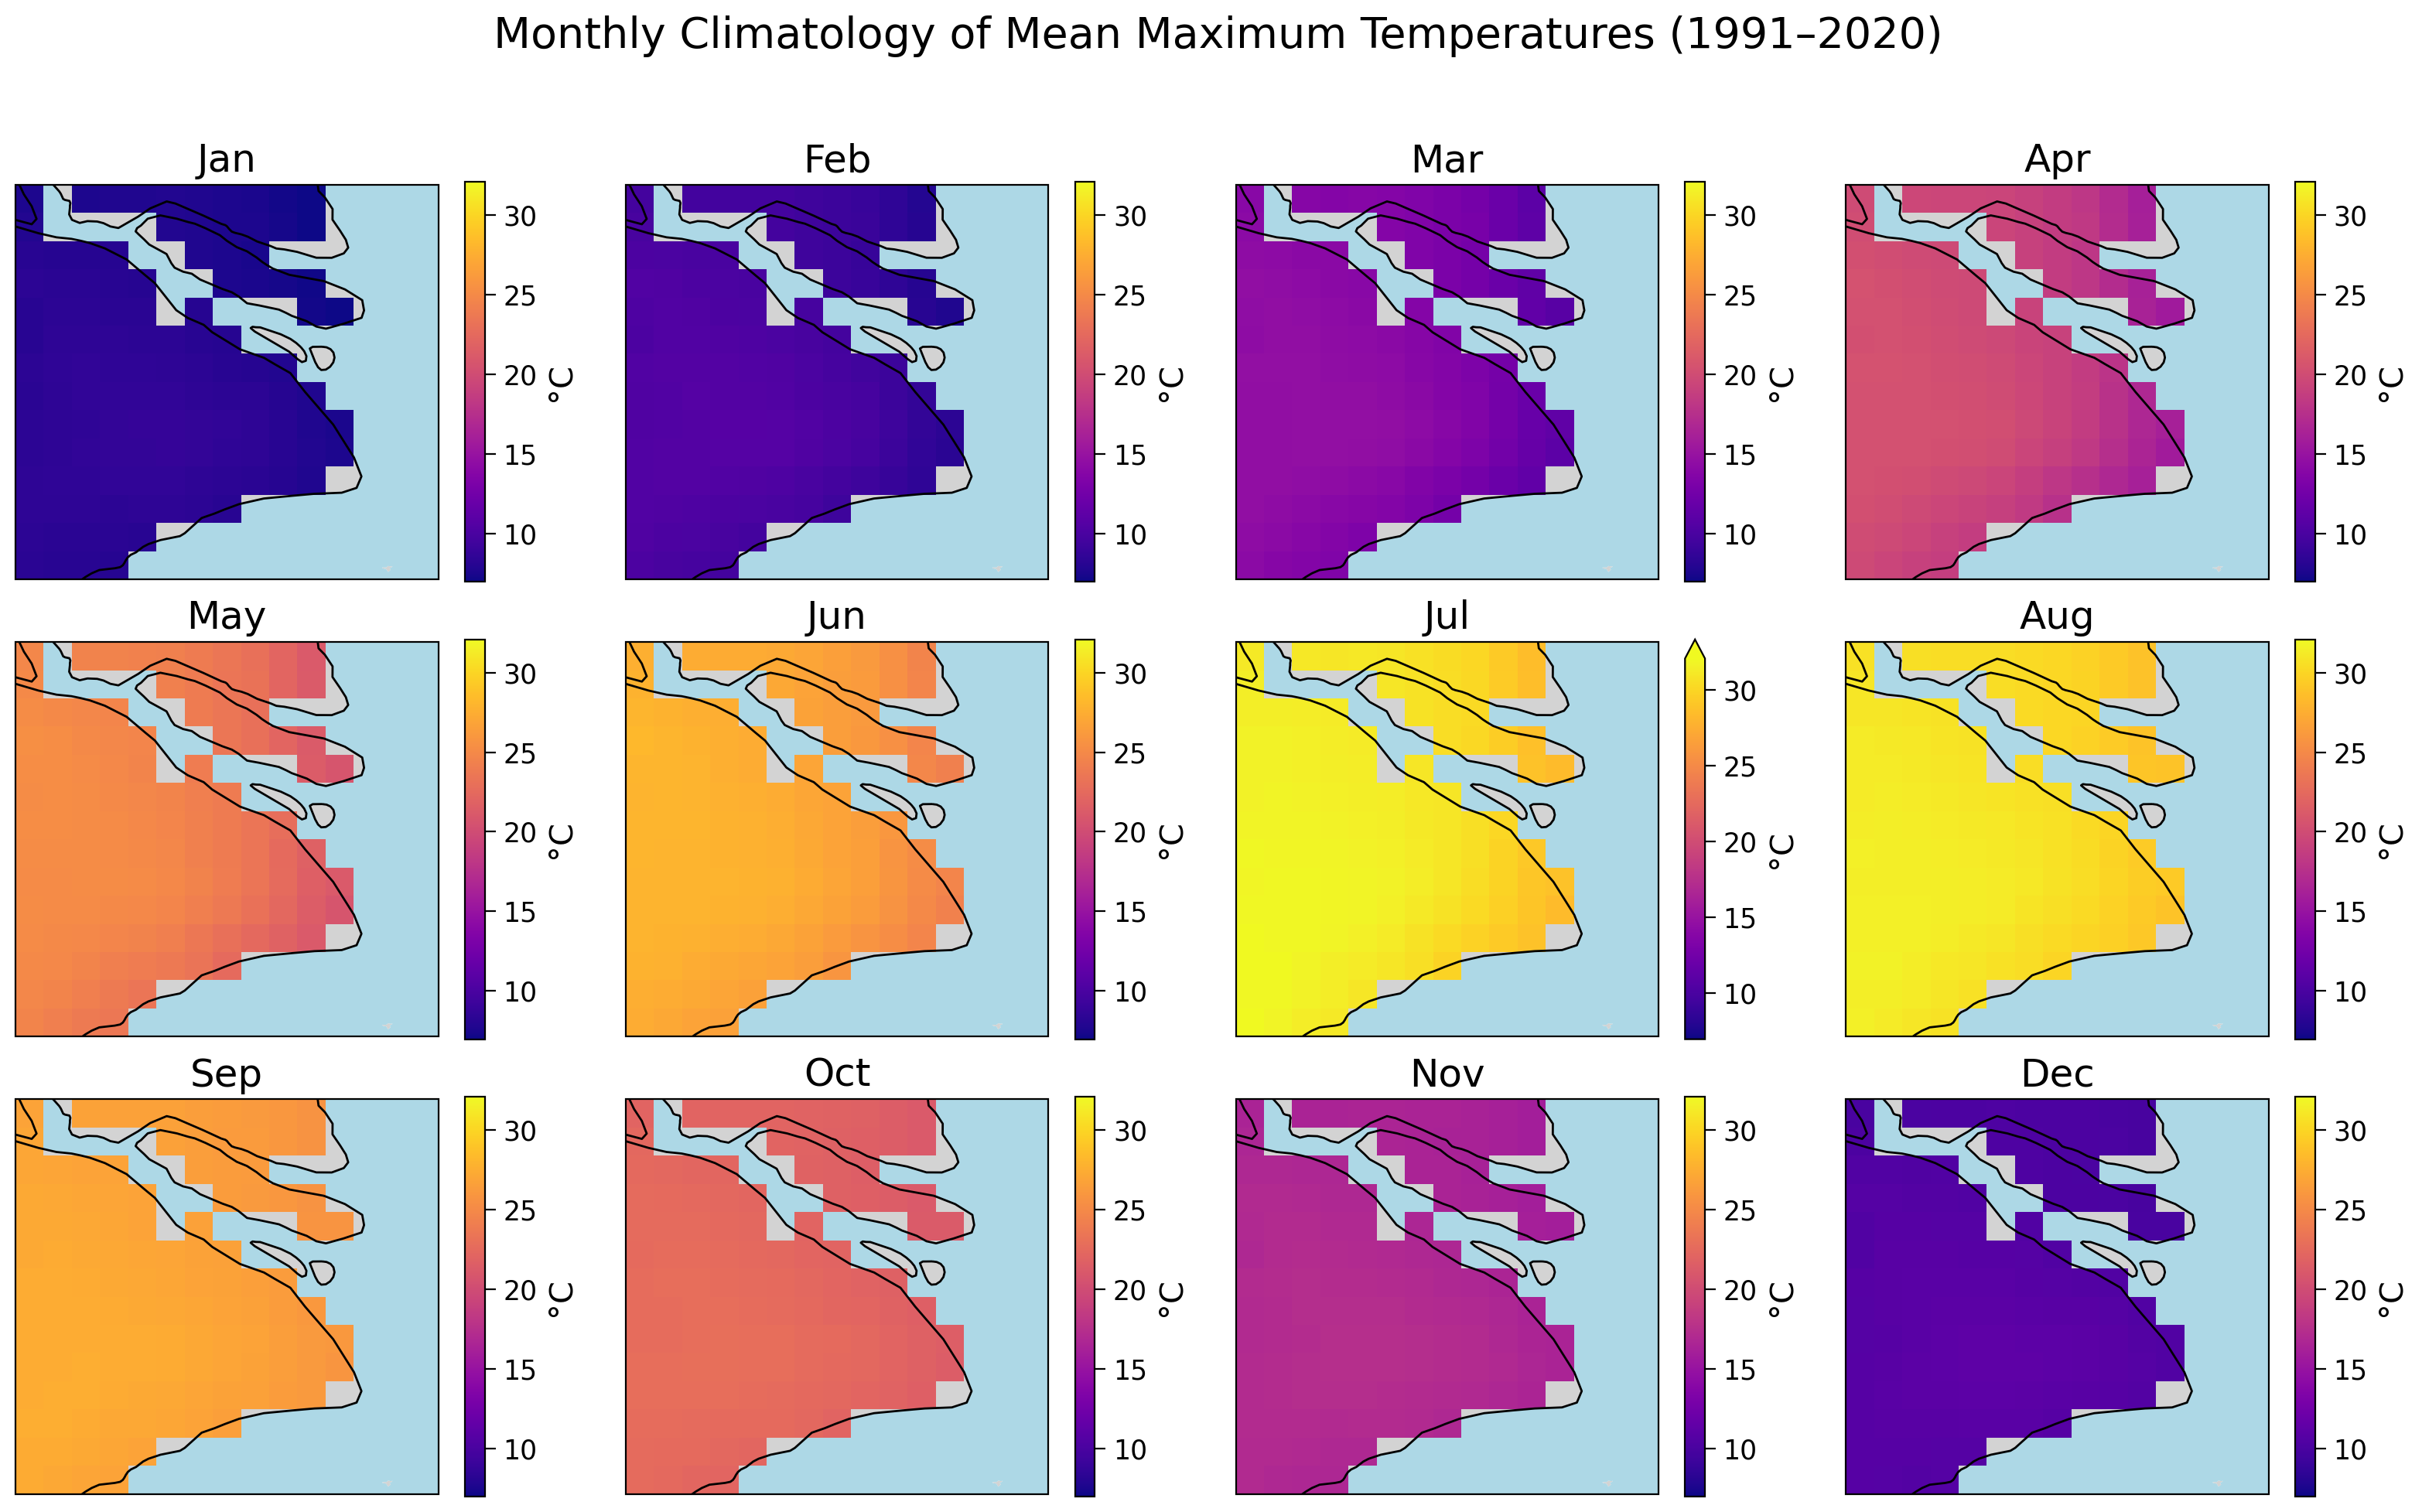

In [26]:

# monthly 1991-2020 plot of maximum temperature
# 5. Tracer une carte pour chaque mois

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                        sharey=True)

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
vmin = monthly_normal_data.min().item() -273.15
vmax = monthly_normal_data.max().item() -273.15

for i, ax in enumerate(axes.flat):
    (monthly_normal_data[i]-273.15).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="plasma",
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={'label': '°C'},
        #add_colorbar=(i == 0)
    )
    ax.set_title(months[i])
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

plt.suptitle("Monthly Climatology of Mean Maximum Temperatures (1991–2020)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [27]:
def compute_rolling_percentile_calendar_day( da,window=15,percentile=90,time_dim='valid_time'):
    """
    Computes a rolling percentile (e.g., 90th) for each calendar day (1–366)
    over multiple years using a moving window (±window days), with wrap-around handling.

    Parameters:
    ----------
    da : xr.DataArray
        Daily data (e.g., maximum temperature) with a time coordinate.
    time_dim : str
        Name of the time dimension. Default is 'time'.
    window : int
        Half-width of the moving window (e.g., 15 → ±15 days).
    percentile : float
        Percentile to compute (e.g., 90 for the 90th percentile).

    Returns:
    --------
    xr.DataArray
        Rolling percentile threshold per calendar day (from day 1 to 366).
    """
    # S'assurer qu'on a bien la coordonnée jour de l'année
    da = da.copy()
    da.coords['dayofyear'] = da[time_dim].dt.dayofyear

    days = np.arange(1, 367)  # 1 à 366
    results = []

    for doy in days:
        # Fenêtre glissante avec wrap-around
        window_days = np.arange(doy - window, doy + window + 1)
        window_days = (window_days - 1) % 366 + 1  # wrap-around

        # Sélection des données
        window_data = da.sel({time_dim: da['dayofyear'].isin(window_days)})

        # Calcul du percentile sur la dimension temporelle
        q = window_data.reduce(np.nanpercentile, q=percentile, dim=time_dim)

        results.append(q)

    # Empilement du résultat sur les jours de l’année
    result_da = xr.concat(results, dim='dayofyear')
    result_da = result_da.assign_coords(dayofyear=days)

    return result_da


In [28]:
# computation of temperature over longitude and latitude to get a time serie for heatwave detection
weights = np.cos(np.deg2rad(data_sh.latitude))
data_ts = (data_sh.weighted(weights).mean(dim=['longitude','latitude']) - 273.15).compute()
data_ts = data_ts.assign_coords({"dayofyear": data_ts.valid_time.dt.dayofyear})
# 90 th percentile computation
normal_ts = data_ts.sel(valid_time=slice('1991','2020'))
normal_ts.assign_coords({"dayofyear": normal_ts.valid_time.dt.dayofyear})
#
normal_90 = normal_ts.groupby('valid_time.dayofyear').quantile(0.90)
normal_90p_ts = normal_90.rolling(dayofyear=15, center=True, min_periods=1).mean()
normal_90p_ts1 = normal_90.rolling(dayofyear=30, center=True, min_periods=1).mean()
# smoothing
# Compare the different 90 th percentile definition
threshold_90_15 = compute_rolling_percentile_calendar_day(normal_ts,7)
threshold_90_30 = compute_rolling_percentile_calendar_day(normal_ts,15)

In [29]:
data_ts.sel(valid_time='2024')

<xarray.Dataset> Size: 9kB
Dimensions:     (valid_time: 366)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
    dayofyear   (valid_time) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Data variables:
    t2m         (valid_time) float64 3kB 7.811 10.27 6.182 ... 8.142 12.27 9.298

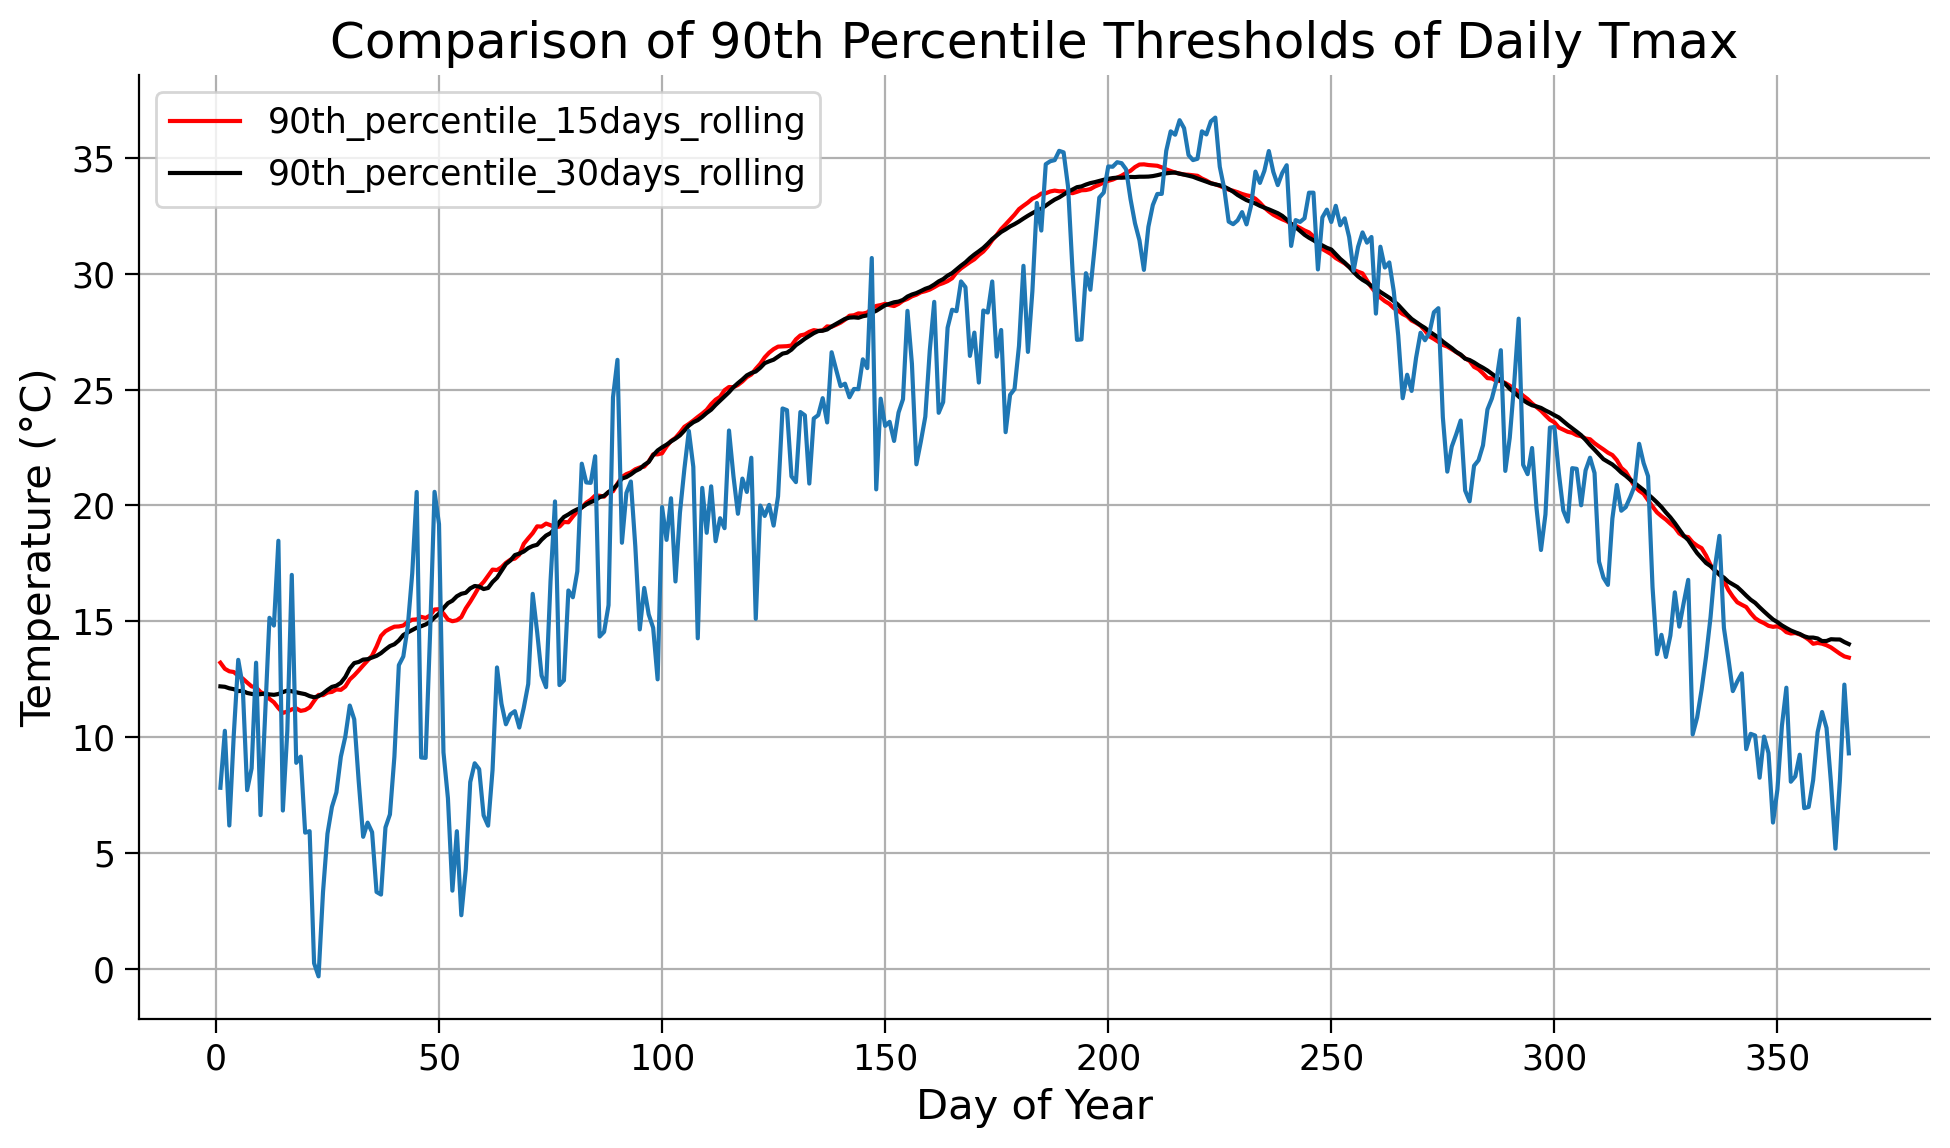

In [30]:
# Compare the different 90 th percentile definition
threshold_90_15 = compute_rolling_percentile_calendar_day(normal_ts,3)
threshold_90_30 = compute_rolling_percentile_calendar_day(normal_ts,15)
#######################"
plt.figure(figsize=(10, 6))

# Vérifie que les objets sont bien des DataArrays ou ont une dimension dayofyear
# Tracer les courbes avec des couleurs distinctes
normal_90p_ts.t2m.plot(label='90th_percentile_15days_rolling', color='red')
normal_90p_ts1.t2m.plot(label='90th_percentile_30days_rolling', color='black')
# threshold_90_15.t2m.plot(label='Rolling ±7 days)', color='green')
# threshold_90_30.t2m.plot(label='Rolling ±15 days', color='orange')
plt.plot(data_ts.t2m.sel(valid_time='2024').valid_time.dt.dayofyear, data_ts.t2m.sel(valid_time='2024'))
mask =  data_ts.t2m.sel(valid_time='2024') > normal_90p_ts1.t2m
#plt.fill_between(data_ts.t2m.sel(valid_time='2024').valid_time.dt.dayofyear, normal_90p_ts1.t2m,data_ts.t2m.sel(valid_time='2024'), where=mask)
#normal_90.t2m.plot(color='red')
# Si tu veux ajouter la climatologie moyenne aussi :
# normal_90.t2m.plot(label='Daily Mean', color='blue')

plt.title("Comparison of 90th Percentile Thresholds of Daily Tmax")
plt.xlabel("Day of Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
#normal_90.t2m.plot(color="red")
#normal_90p_ts.t2m.plot(color="blue")
# normal_90p_ts1.t2m.plot(color="black")
# threshold_90_15.t2m.plot(color='green')
# threshold_90_30.t2m.plot(color='yellow')

#### 2024 heat waves visualisation

We will use this definition for the calculation of 90th percentile:
``` python
normal_90 = normal_ts.groupby('valid_time.dayofyear').quantile(0.90)
normal_90p_ts1 = normal_90.rolling(dayofyear=30, center=True, min_periods=1).mean()
```



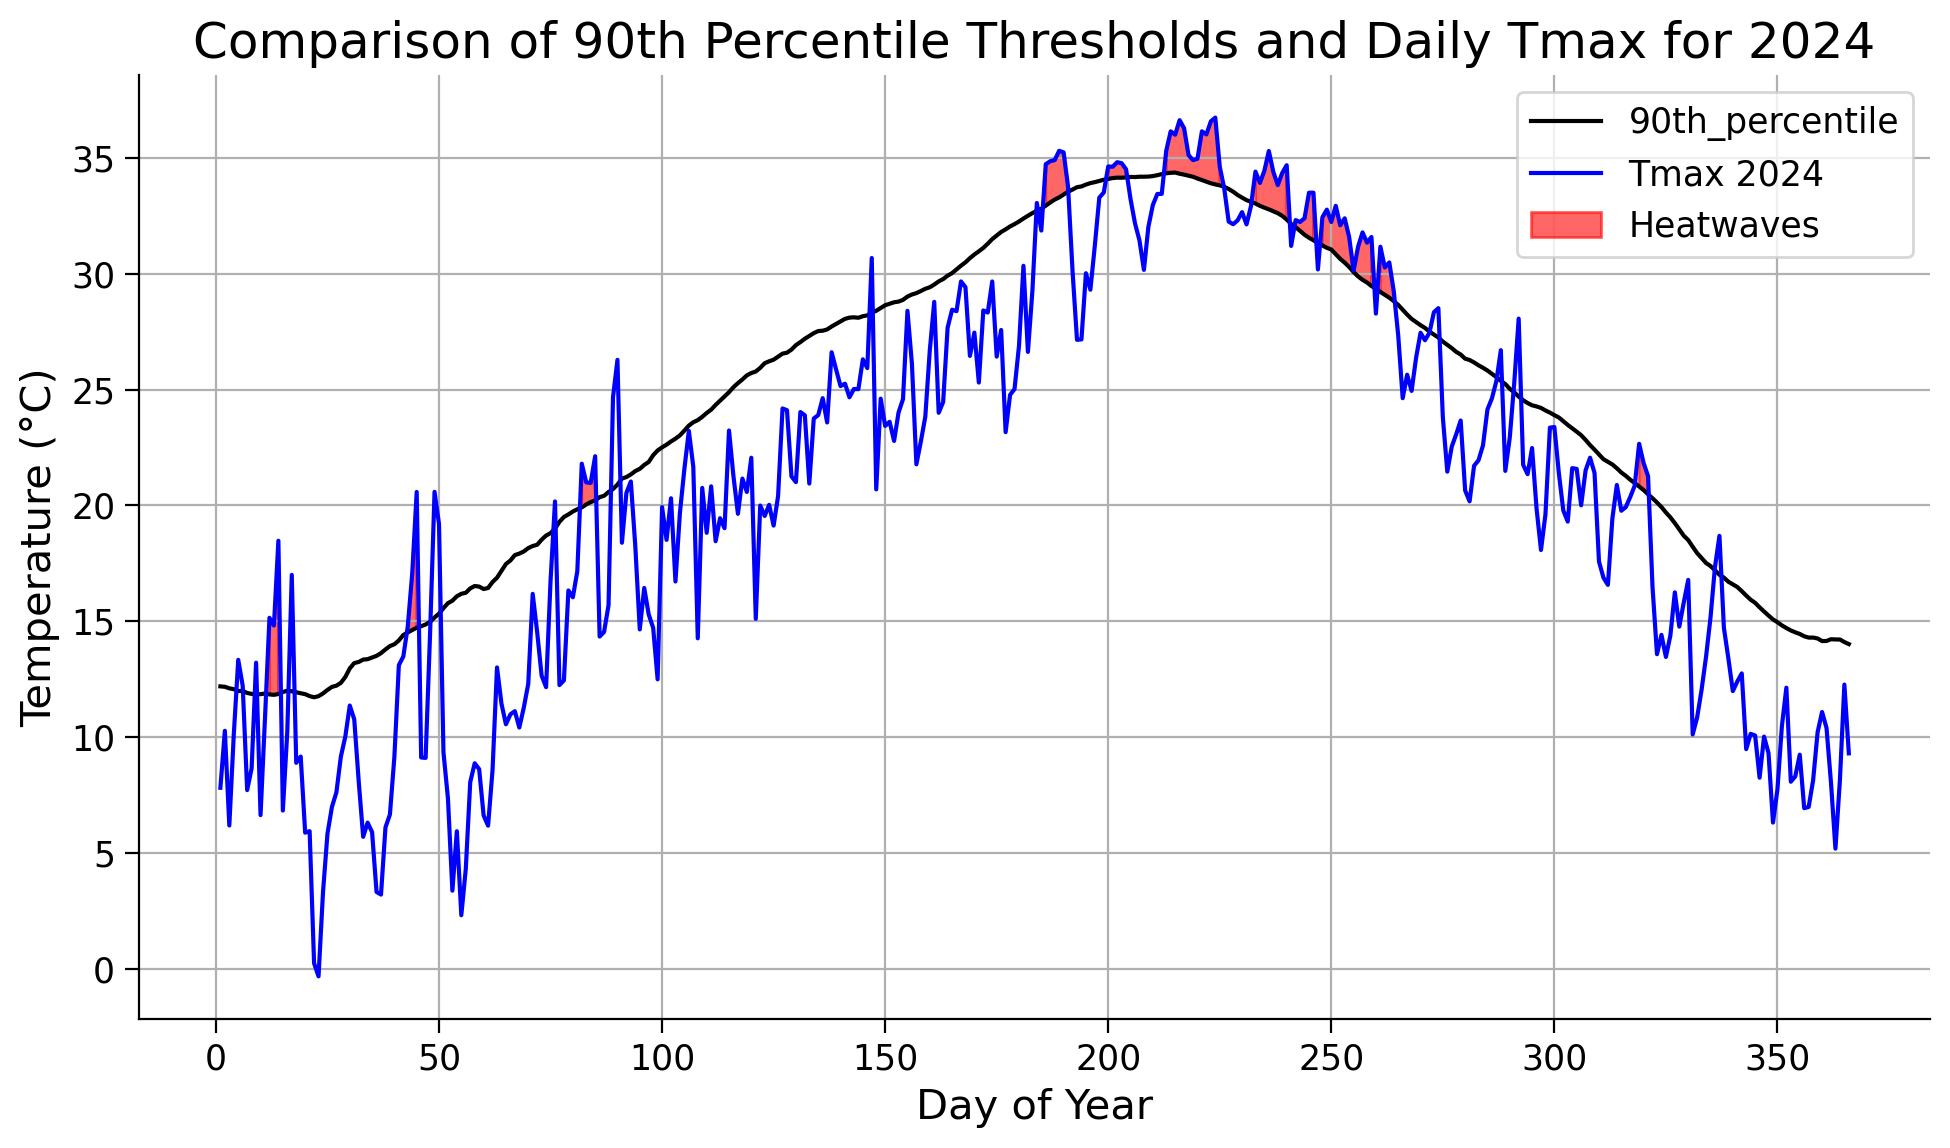

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# Étape 1 : Extraire les températures et seuils
t2m_2024 = data_ts.t2m.sel(valid_time='2024')
dayofyear = t2m_2024.valid_time.dt.dayofyear
t2m_vals = t2m_2024.values
threshold_vals = normal_90p_ts1.t2m.values  # 90e percentile (30 jours)

# Étape 2 : Masque binaire (1 si dépassement)
mask = (t2m_vals > threshold_vals).astype(int)

# Étape 3 : Identifier les groupes de dépassements
labels, num_events = label(mask)

# Étape 4 : Construire le masque final (vagues de chaleur uniquement)
vague_mask = np.zeros_like(mask, dtype=bool)
for i in range(1, num_events + 1):
    indices = np.where(labels == i)[0]
    if len(indices) >= 3:  # condition vague de chaleur : ≥ 3 jours consécutifs
        vague_mask[indices] = True

# Étape 5 : Préparer les valeurs à tracer
filled_vals = np.where(vague_mask, t2m_vals, np.nan)

# === Tracé ===
plt.figure(figsize=(10, 6))
normal_90p_ts1.t2m.plot(label='90th_percentile', color='black')
plt.plot(dayofyear, t2m_vals, label="Tmax 2024", color="blue")

# Remplissage uniquement des vagues de chaleur
plt.fill_between(dayofyear, threshold_vals, filled_vals, where=vague_mask, color="red", alpha=0.6, label="Heatwaves")

plt.title("Comparison of 90th Percentile Thresholds and Daily Tmax for 2024")
plt.xlabel("Day of Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### heat waves detection

In [36]:
## Heatwaves detection
#ds_clim_avg_ts = data_ts.rolling(dayofyear=30, center=True, min_periods=1).mean()
MHW_ind = data_ts.groupby('dayofyear') - normal_90p_ts1
heat_flag = (MHW_ind >= 0)#.astype(int)
###
nb_1 = int((heat_flag.t2m == True).sum())
nb_0 = int((heat_flag.t2m == False).sum())
print(f"Nombre de jours au-dessus du seuil (True) : {nb_1}")
print(f"Nombre de jours en-dessous ou au seuil (False) : {nb_0}")


Nombre de jours au-dessus du seuil (True) : 1565
Nombre de jours en-dessous ou au seuil (False) : 10854


There are **1565** days for which the temperature is above the 90th percentile

In [40]:
def filter_short_true_runs(arr, min_length=3):
    labels, num = label(arr)  # Regroupe les blocs de 1 consécutifs (ou True)
    counts = np.bincount(labels)  # Compte la taille de chaque bloc
    valid = np.isin(labels, np.where(counts >= min_length)[0])  # Garde uniquement les blocs de taille >= min_length
    return valid & arr  # Ne garde que les True qui appartiennent aux bons blocs
MHW_ind_filtered = filter_short_true_runs(heat_flag.t2m,3)

In [42]:
############
# data for a year

labels, num = label(MHW_ind_filtered)
counts = np.bincount(labels)
print(f'Number of MHW events : {num}')
print(f'Max duration of MHW events : {max(counts[1:])} days')
print(f'Median duration of MHW events : {np.median(counts[1:])} days')

tmax_masked = np.where(MHW_ind_filtered,MHW_ind.t2m , np.nan)

print(f'Mean intensity of MHW events : + {np.nanmean(tmax_masked)} °C above 1991-2020 climatology')
print(f'Max intensity of MHW events : + {np.nanmax(tmax_masked)} °C above 1991-2020 climatology')


Number of MHW events : 190
Max duration of MHW events : 14 days
Median duration of MHW events : 3.5 days
Mean intensity of MHW events : + 1.9591981712418691 °C above 1991-2020 climatology
Max intensity of MHW events : + 9.990986153830413 °C above 1991-2020 climatology


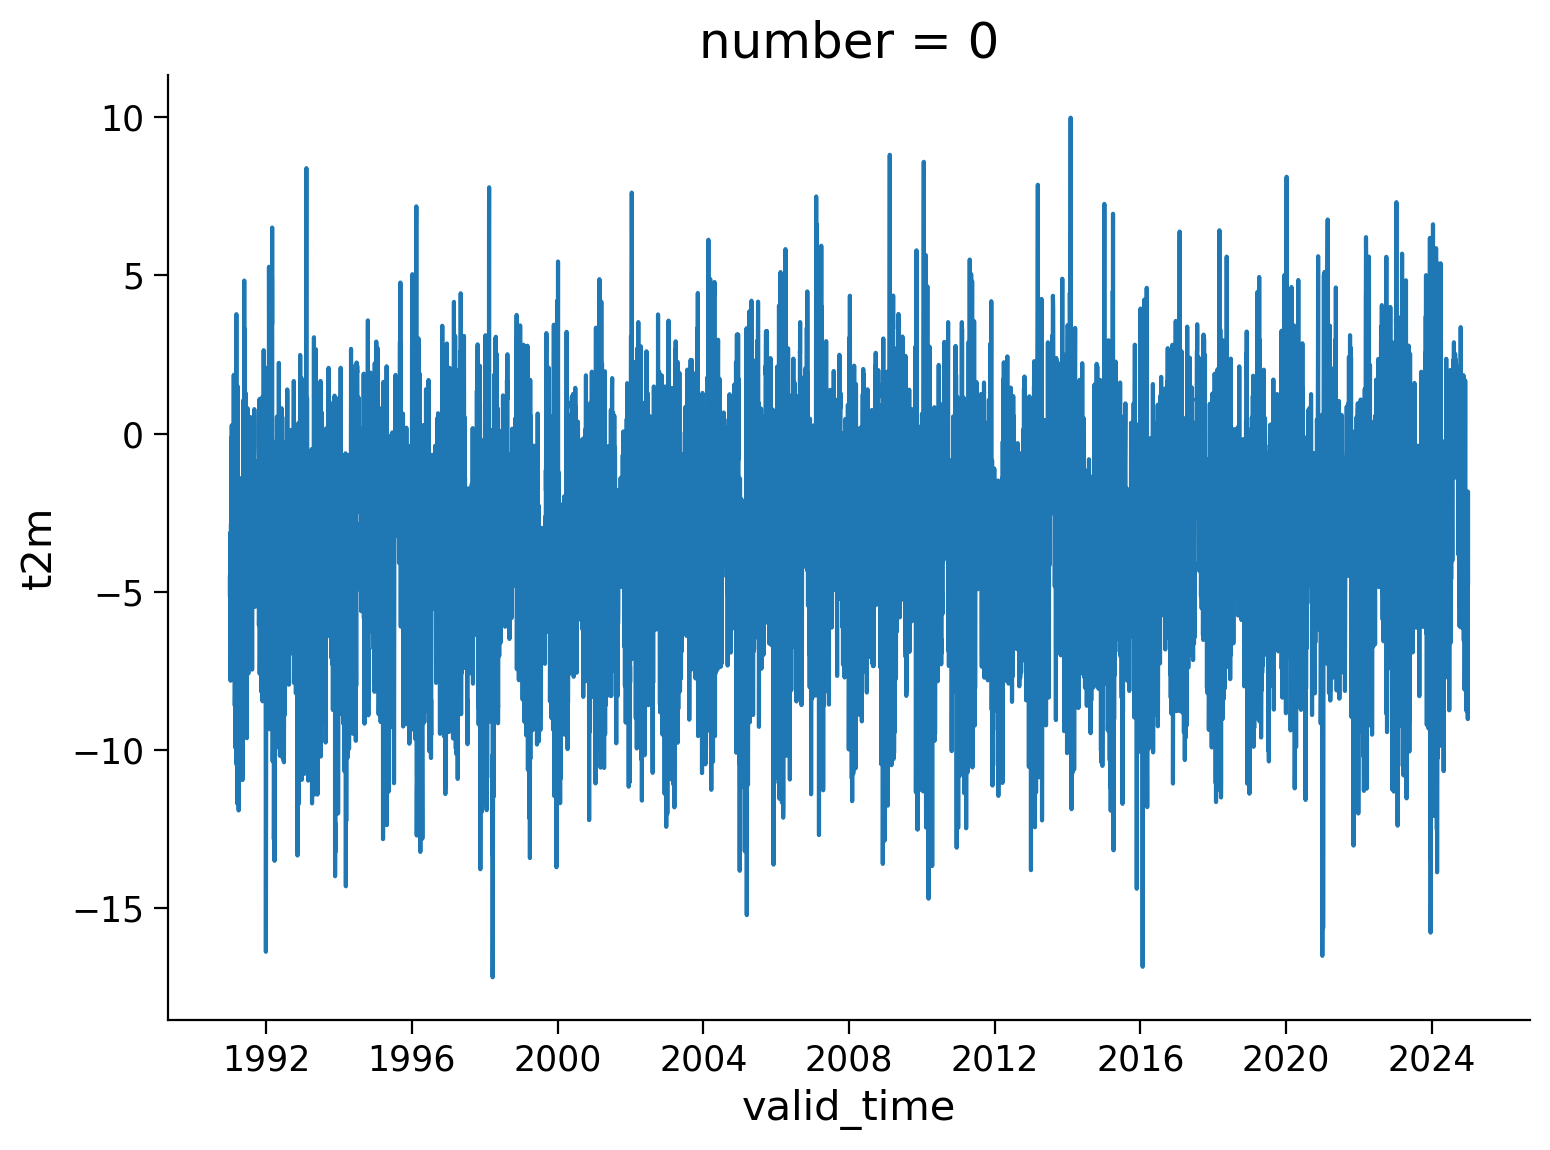

In [43]:
MHW_ind.t2m.plot()


## Heatwaves events over the years

In [44]:
#computing the indicators

nums = []
max_d = []
med_d = []

avg_t = []
max_t = []


#MHW_ind_filtered.sel(valid_time='2024')
for year in np.unique(MHW_ind_filtered['valid_time.year'].data):
    MHW_ind = data_ts.sel(valid_time=str(year)).groupby('dayofyear') - normal_90p_ts1
    heat_flag = (MHW_ind >= 0)#.astype(int)
    MHW_ind_filtered = filter_short_true_runs(heat_flag.t2m,3)
    
    labels, num = label(MHW_ind_filtered)
    nums.append(num)
    counts = np.bincount(labels)
    if num > 0:
        max_d.append(max(counts[1:]))
        med_d.append(np.median(counts[1:]))
        
        #sst_masked = np.where(MHW_ind_filtered, sst.data - ds_clim_avg_ts.analysed_sst+273.15 , np.nan)
        sst_masked = np.where(MHW_ind_filtered,MHW_ind.t2m , np.nan)

        avg_t.append(np.nanmean(sst_masked))
        max_t.append(np.nanmax(sst_masked))
    else:
        max_d.append(0)
        med_d.append(0)
        avg_t.append(0)
        max_t.append(0)



In [45]:
np.unique(data_ts['valid_time.year'].data)

array([1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024])

In [46]:
import pandas as pd
from scipy.ndimage import label

# Initialiser la liste pour stocker les résultats
heatwave_records = []

# Boucle sur les années disponibles
for year in np.unique(data_ts['valid_time.year'].data):
    
    # Étape 1 : calcul de l’anomalie pour cette année
    MHW_ind = data_ts.sel(valid_time=str(year)).groupby('dayofyear') - normal_90p_ts1
    heat_flag = (MHW_ind > 0).astype(int)

    # Étape 2 : filtrer les séquences < 3 jours
    heat_flag_filtered = filter_short_true_runs(heat_flag.t2m, 3)

    # Étape 3 : identifier les séquences avec label()
    labels, num_events = label(heat_flag_filtered)

    # Étape 4 : récupérer les dates et les valeurs
    times = data_ts.sel(valid_time=str(year)).valid_time.values
    anomalies = MHW_ind.t2m.values  # les intensités jour par jour

    for event_id in range(1, num_events + 1):
        indices = np.where(labels == event_id)[0]
        if len(indices) < 3:
            continue  # sécurité, même si le filtre est déjà appliqué

        # Dates
        start_date = times[indices[0]]
        end_date = times[indices[-1]]
        duration = len(indices)

        # Day of year (entre 1 et 366)
        start_doy = pd.to_datetime(start_date).dayofyear
        end_doy = pd.to_datetime(end_date).dayofyear

        # Intensités (Tmax - seuil)
        intensities = anomalies[indices]

        # Sauvegarde des infos dans un dictionnaire
        heatwave_records.append({
            'year': year,
            'start_date': str(start_date)[:10],
            'end_date': str(end_date)[:10],
            'start_doy': start_doy,
            'end_doy': end_doy,
            'duration': duration,
            'min_intensity': float(np.nanmin(intensities)),
            'mean_intensity': float(np.nanmean(intensities)),
            'median_intensity': float(np.nanmedian(intensities)),
            'max_intensity': float(np.nanmax(intensities)),
            
        })

# Convertir en DataFrame final
df_heatwaves = pd.DataFrame(heatwave_records)


In [47]:
df_heatwaves

,year,start_date,end_date,start_doy,end_doy,duration,min_intensity,mean_intensity,median_intensity,max_intensity
0,1991,1991-09-03,1991-09-05,246,248,3,0.131027,0.502082,0.604251,0.770968
1,1991,1991-12-05,1991-12-07,339,341,3,1.828711,2.275337,2.361798,2.635504
2,1992,1992-01-27,1992-01-29,27,29,3,0.170571,3.028546,3.641528,5.273538
3,1992,1992-02-26,1992-02-29,57,60,4,0.954923,3.962766,4.190553,6.515036
4,1992,1992-05-28,1992-05-30,149,151,3,0.367106,0.541505,0.520881,0.736528
...,...,...,...,...,...,...,...,...,...,...
184,2024,2024-08-20,2024-08-27,233,240,8,0.989007,1.699064,1.648219,2.518333
185,2024,2024-08-29,2024-09-02,242,246,5,0.305656,1.080665,0.712084,2.054695
186,2024,2024-09-04,2024-09-15,248,259,12,0.061071,1.502327,1.549394,2.118556
187,2024,2024-09-17,2024-09-20,261,264,4,0.427113,1.271352,1.352679,1.952935


In [48]:
# Agrégation des indicateurs annuels depuis le tableau des vagues
grouped = df_heatwaves.groupby('year')

# Nombre d'événements par an
nums = grouped.size().values

# Durée max et médiane par an
max_d = grouped['duration'].max().values
med_d = grouped['duration'].median().values

# Intensité moyenne et maximale par an
avg_t = grouped['mean_intensity'].mean().values
max_t = grouped['max_intensity'].max().values

# Liste des années (assure l’ordre)
x = grouped.size().index.values


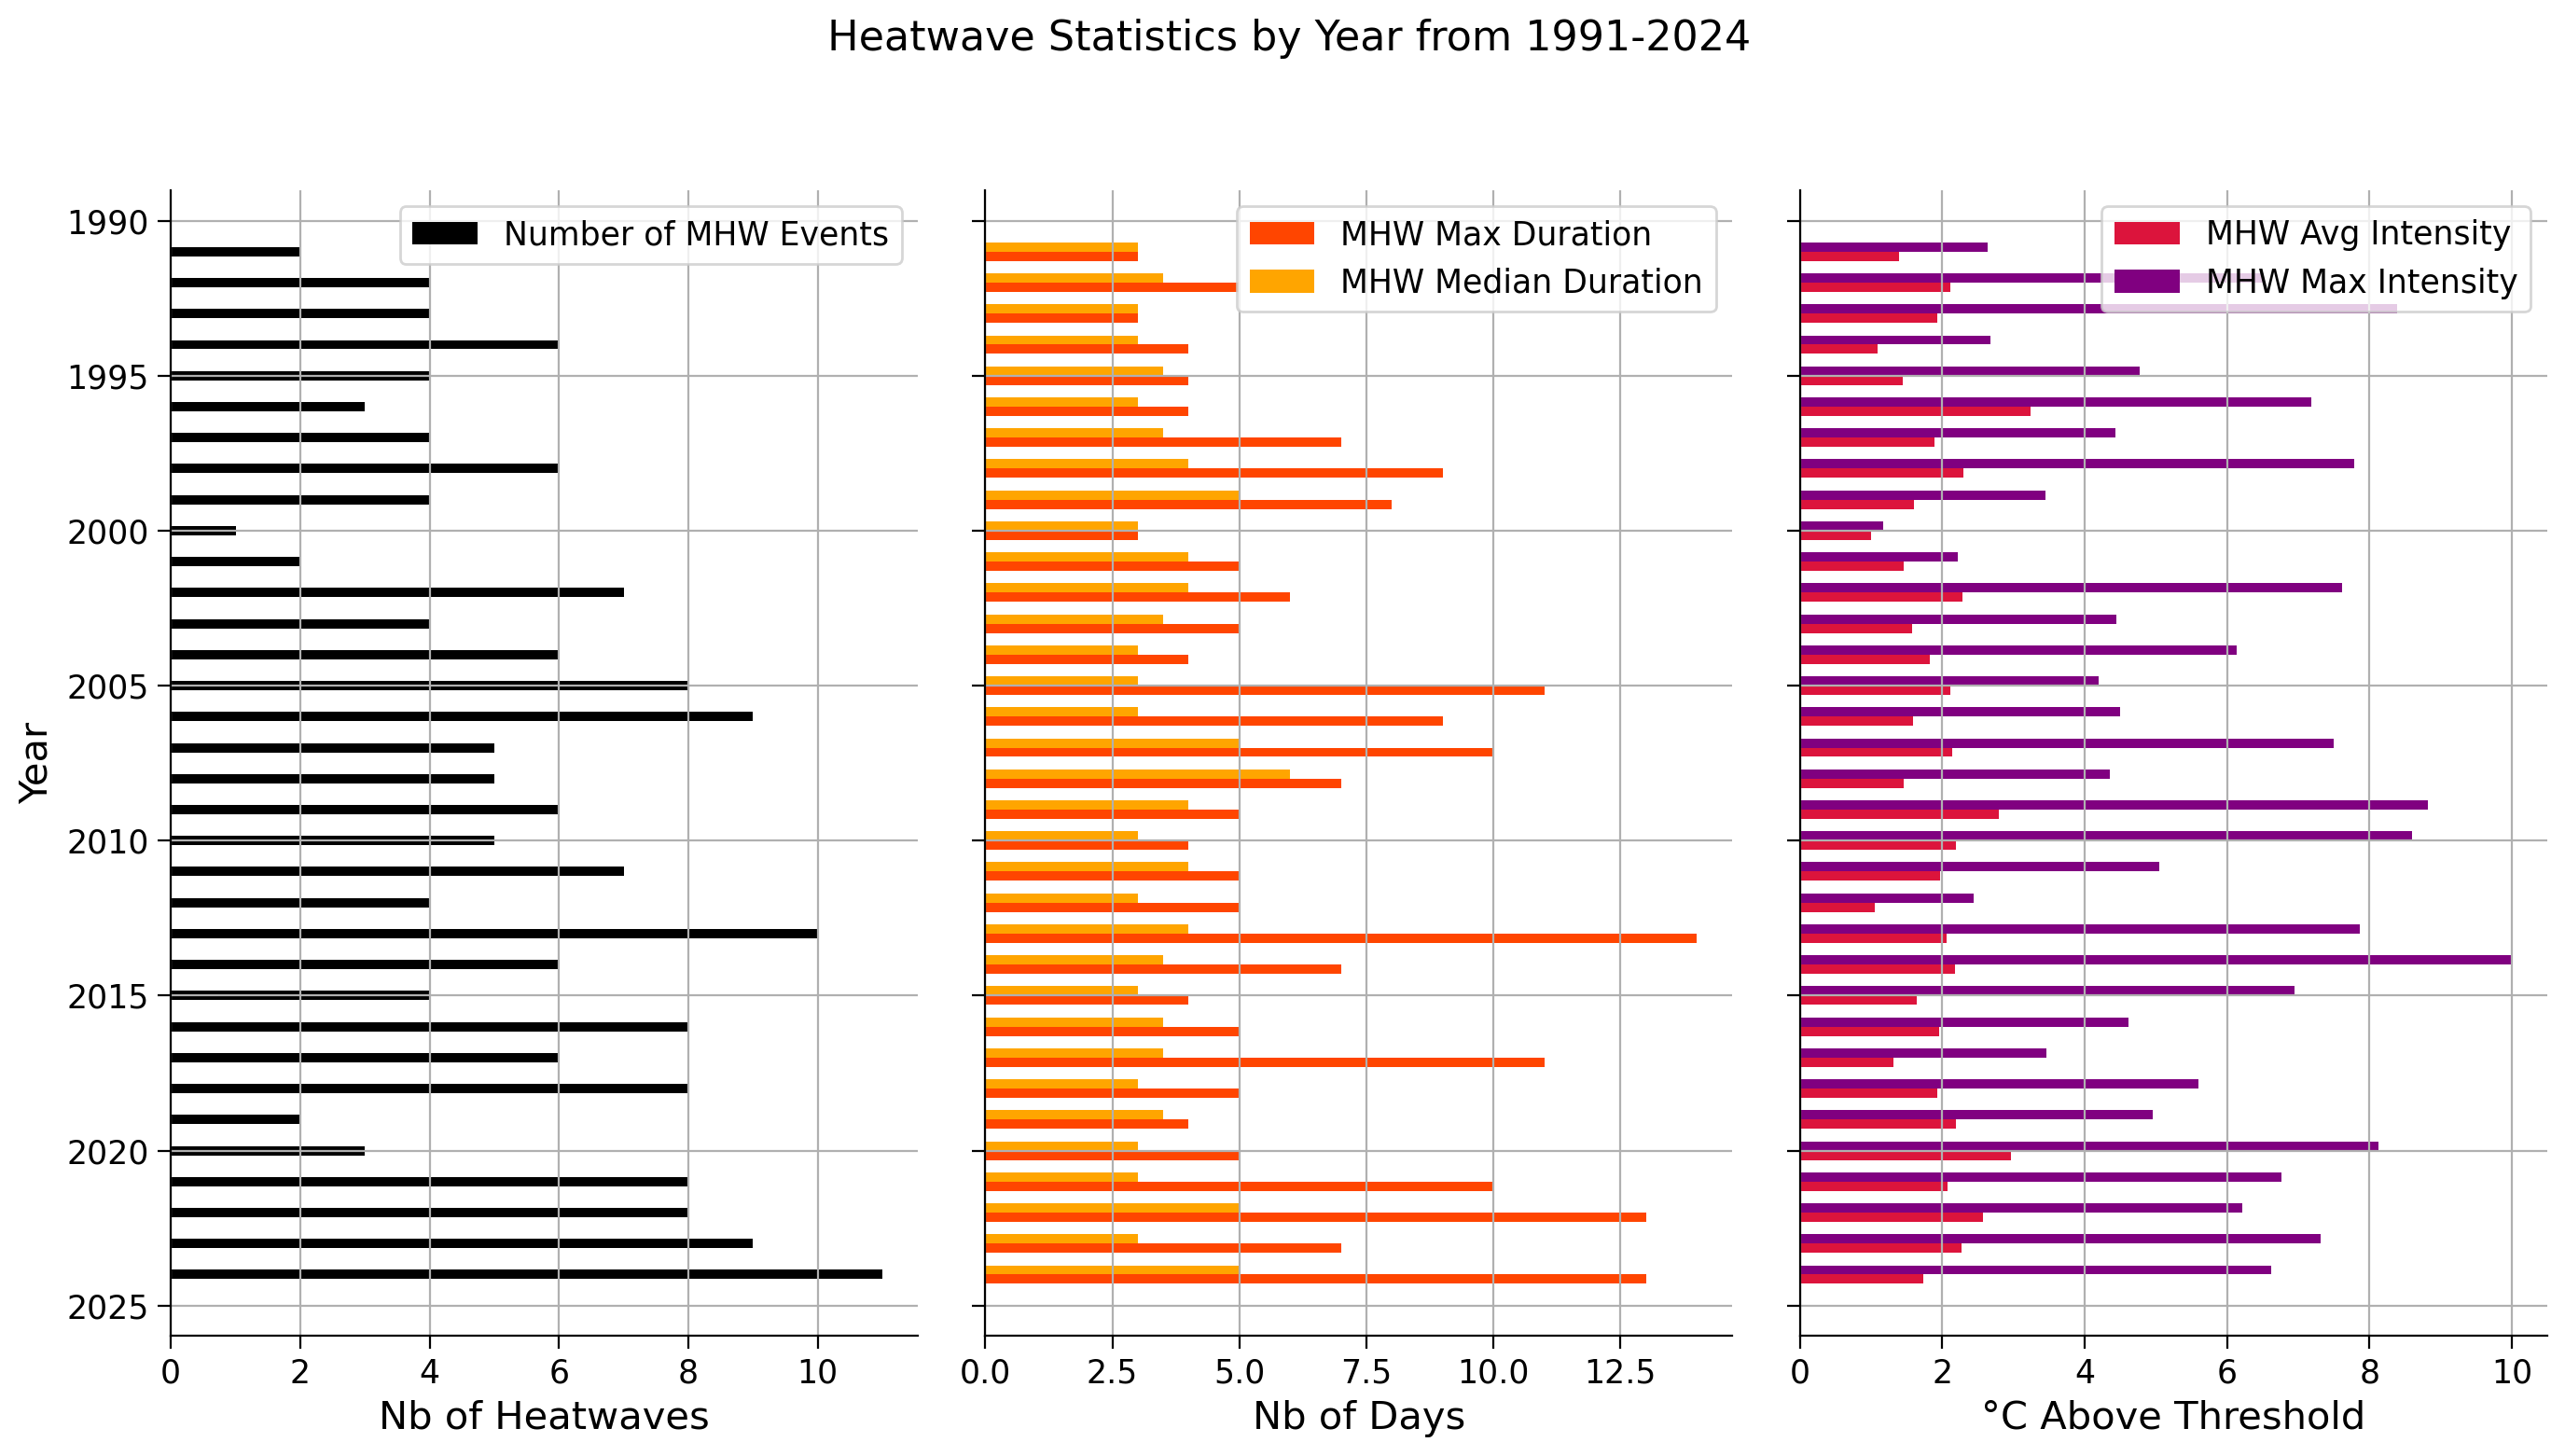

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# S'assurer que x est un tableau numpy
x = np.array(x)

fig, axes = plt.subplots(1, 3, figsize=(14, 8), sharey=True)

# Plot 1 : nombre de vagues par an
axes[0].barh(x, nums, height=0.3, label='Number of MHW Events', color='k')
axes[0].invert_yaxis()
axes[0].grid(True)
axes[0].legend()
axes[0].set_ylabel("Year")
axes[0].set_xlabel('Nb of Heatwaves')

# Plot 2 : durées
axes[1].barh(x + 0.15, max_d, height=0.3, label='MHW Max Duration', color='orangered')
axes[1].barh(x - 0.15, med_d, height=0.3, label='MHW Median Duration', color='orange')
axes[1].invert_yaxis()
axes[1].grid(True)
axes[1].legend()
axes[1].set_xlabel('Nb of Days')

# Plot 3 : intensités
axes[2].barh(x + 0.15, avg_t, height=0.3, label='MHW Avg Intensity', color='crimson')
axes[2].barh(x - 0.15, max_t, height=0.3, label='MHW Max Intensity', color='purple')
axes[2].invert_yaxis()
axes[2].grid(True)
axes[2].legend()
axes[2].set_xlabel('°C Above Threshold')

plt.suptitle(" Heatwave Statistics by Year from 1991-2024", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


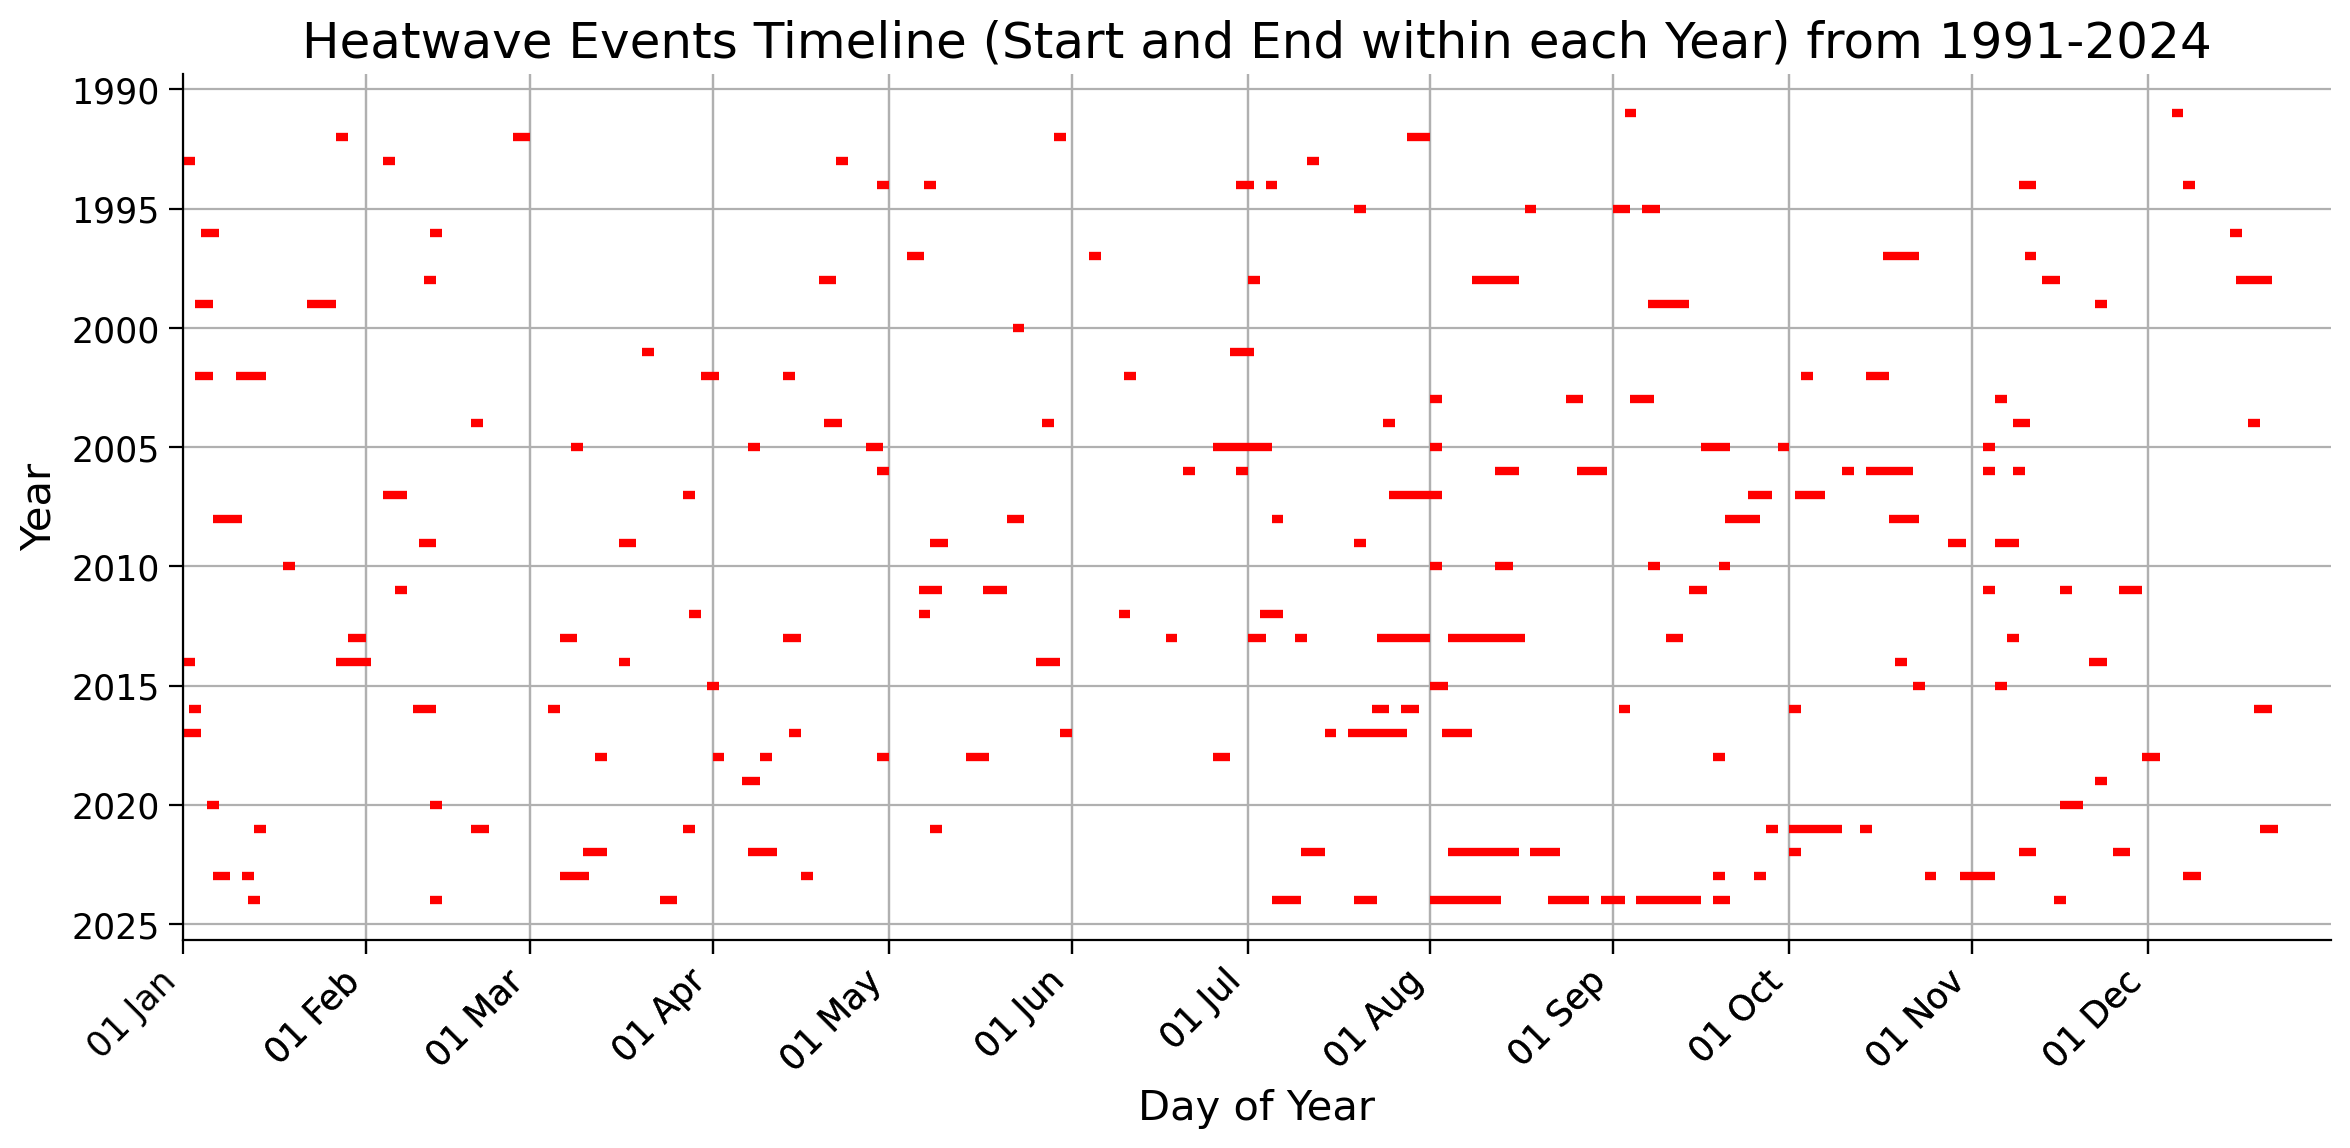

In [50]:
import matplotlib.pyplot as plt

# Générer les dates du 1er et 15 de chaque mois (année fictive non bissextile)
dates = pd.date_range("2001-01-01", "2001-12-31", freq="MS").tolist() + \
        pd.date_range("2001-01-15", "2001-12-15", freq="MS").tolist()

dates = sorted(dates)  # trier chronologiquement

# Ticks en dayofyear
tick_positions = [d.dayofyear for d in dates]
tick_labels = [d.strftime("%d %b") for d in dates]  # ex: "01 Jan", "15 Jan"

fig, ax = plt.subplots(figsize=(12, 6))

# Tracer chaque vague comme une ligne horizontale
for _, row in df_heatwaves.iterrows():
    y = row['year']
    x_start = row['start_doy']
    x_end = row['end_doy']
    ax.hlines(y=y, xmin=x_start, xmax=x_end, color='red', linewidth=3)

# Mise en forme
ax.set_xlabel("Day of Year")
ax.set_ylabel("Year")
ax.set_title("Heatwave Events Timeline (Start and End within each Year) from 1991-2024")
ax.grid(True)
ax.set_xlim(1, 366)
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.invert_yaxis()  # pour avoir les années récentes en haut (facultatif)
plt.tight_layout()
plt.show()


In [51]:
df_stats = pd.DataFrame({
    'year': x,
    'num_events': nums,
    'max_duration': max_d,
    'med_duration': med_d,
    'avg_intensity': avg_t,
    'max_intensity': max_t
})


In [52]:
df_stats.to_csv("../data/yearly_statistics.csv")

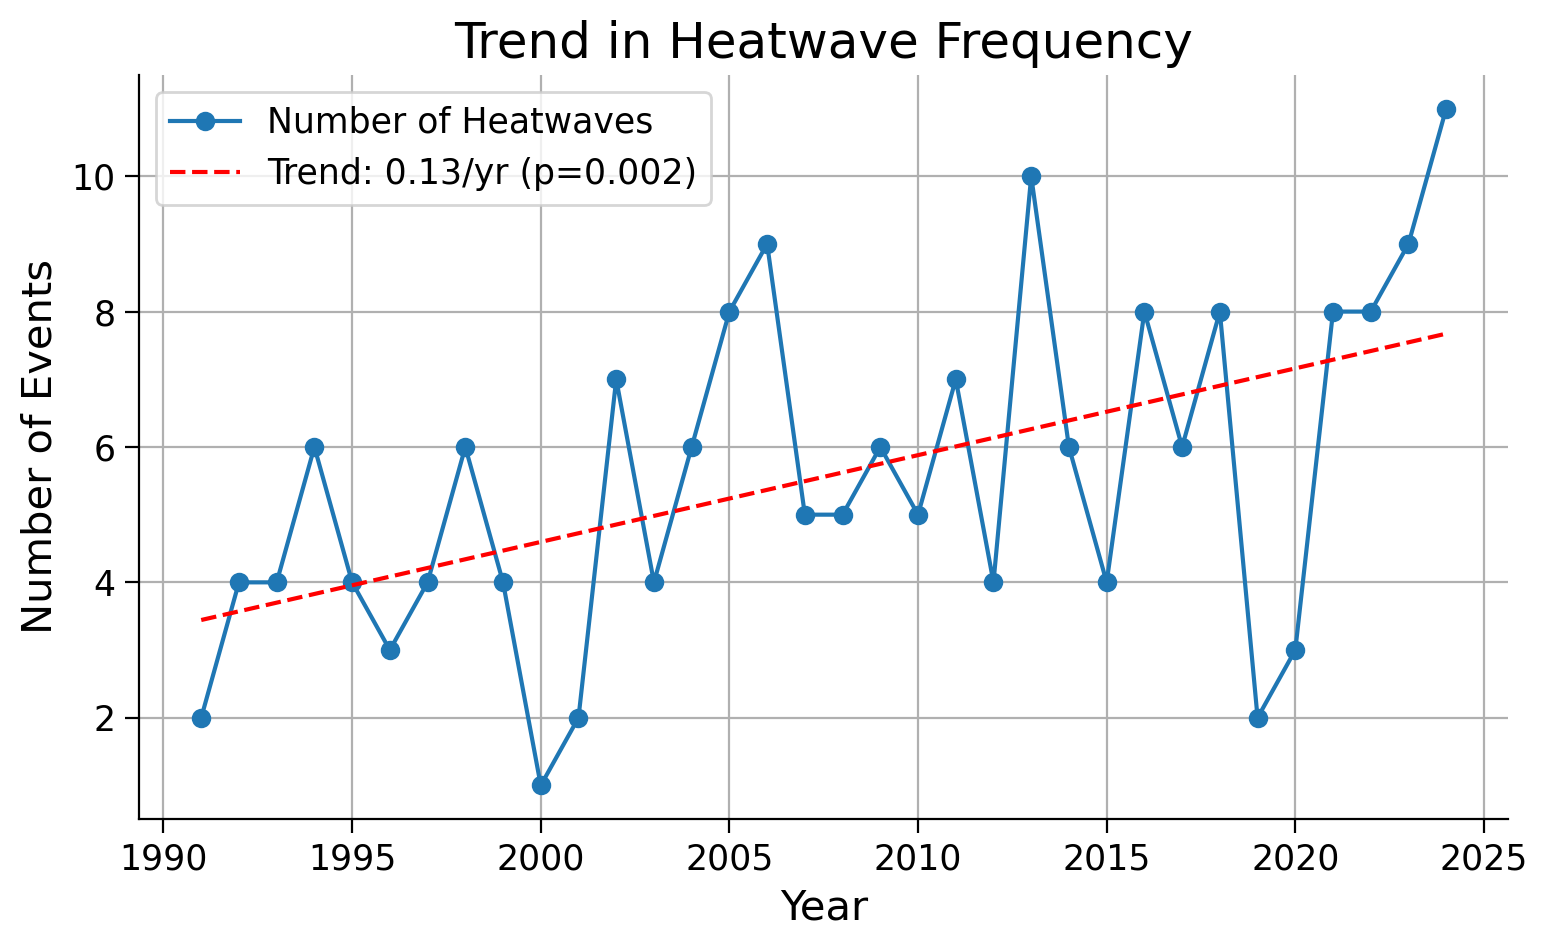

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Variable à analyser
years = df_stats['year']
values = df_stats['num_events']

# Régression linéaire
slope, intercept, r_value, p_value, std_err = linregress(years, values)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(years, values, 'o-', label='Number of Heatwaves')
plt.plot(years, intercept + slope * years, 'r--', label=f'Trend: {slope:.2f}/yr (p={p_value:.3f})')
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.title("Trend in Heatwave Frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


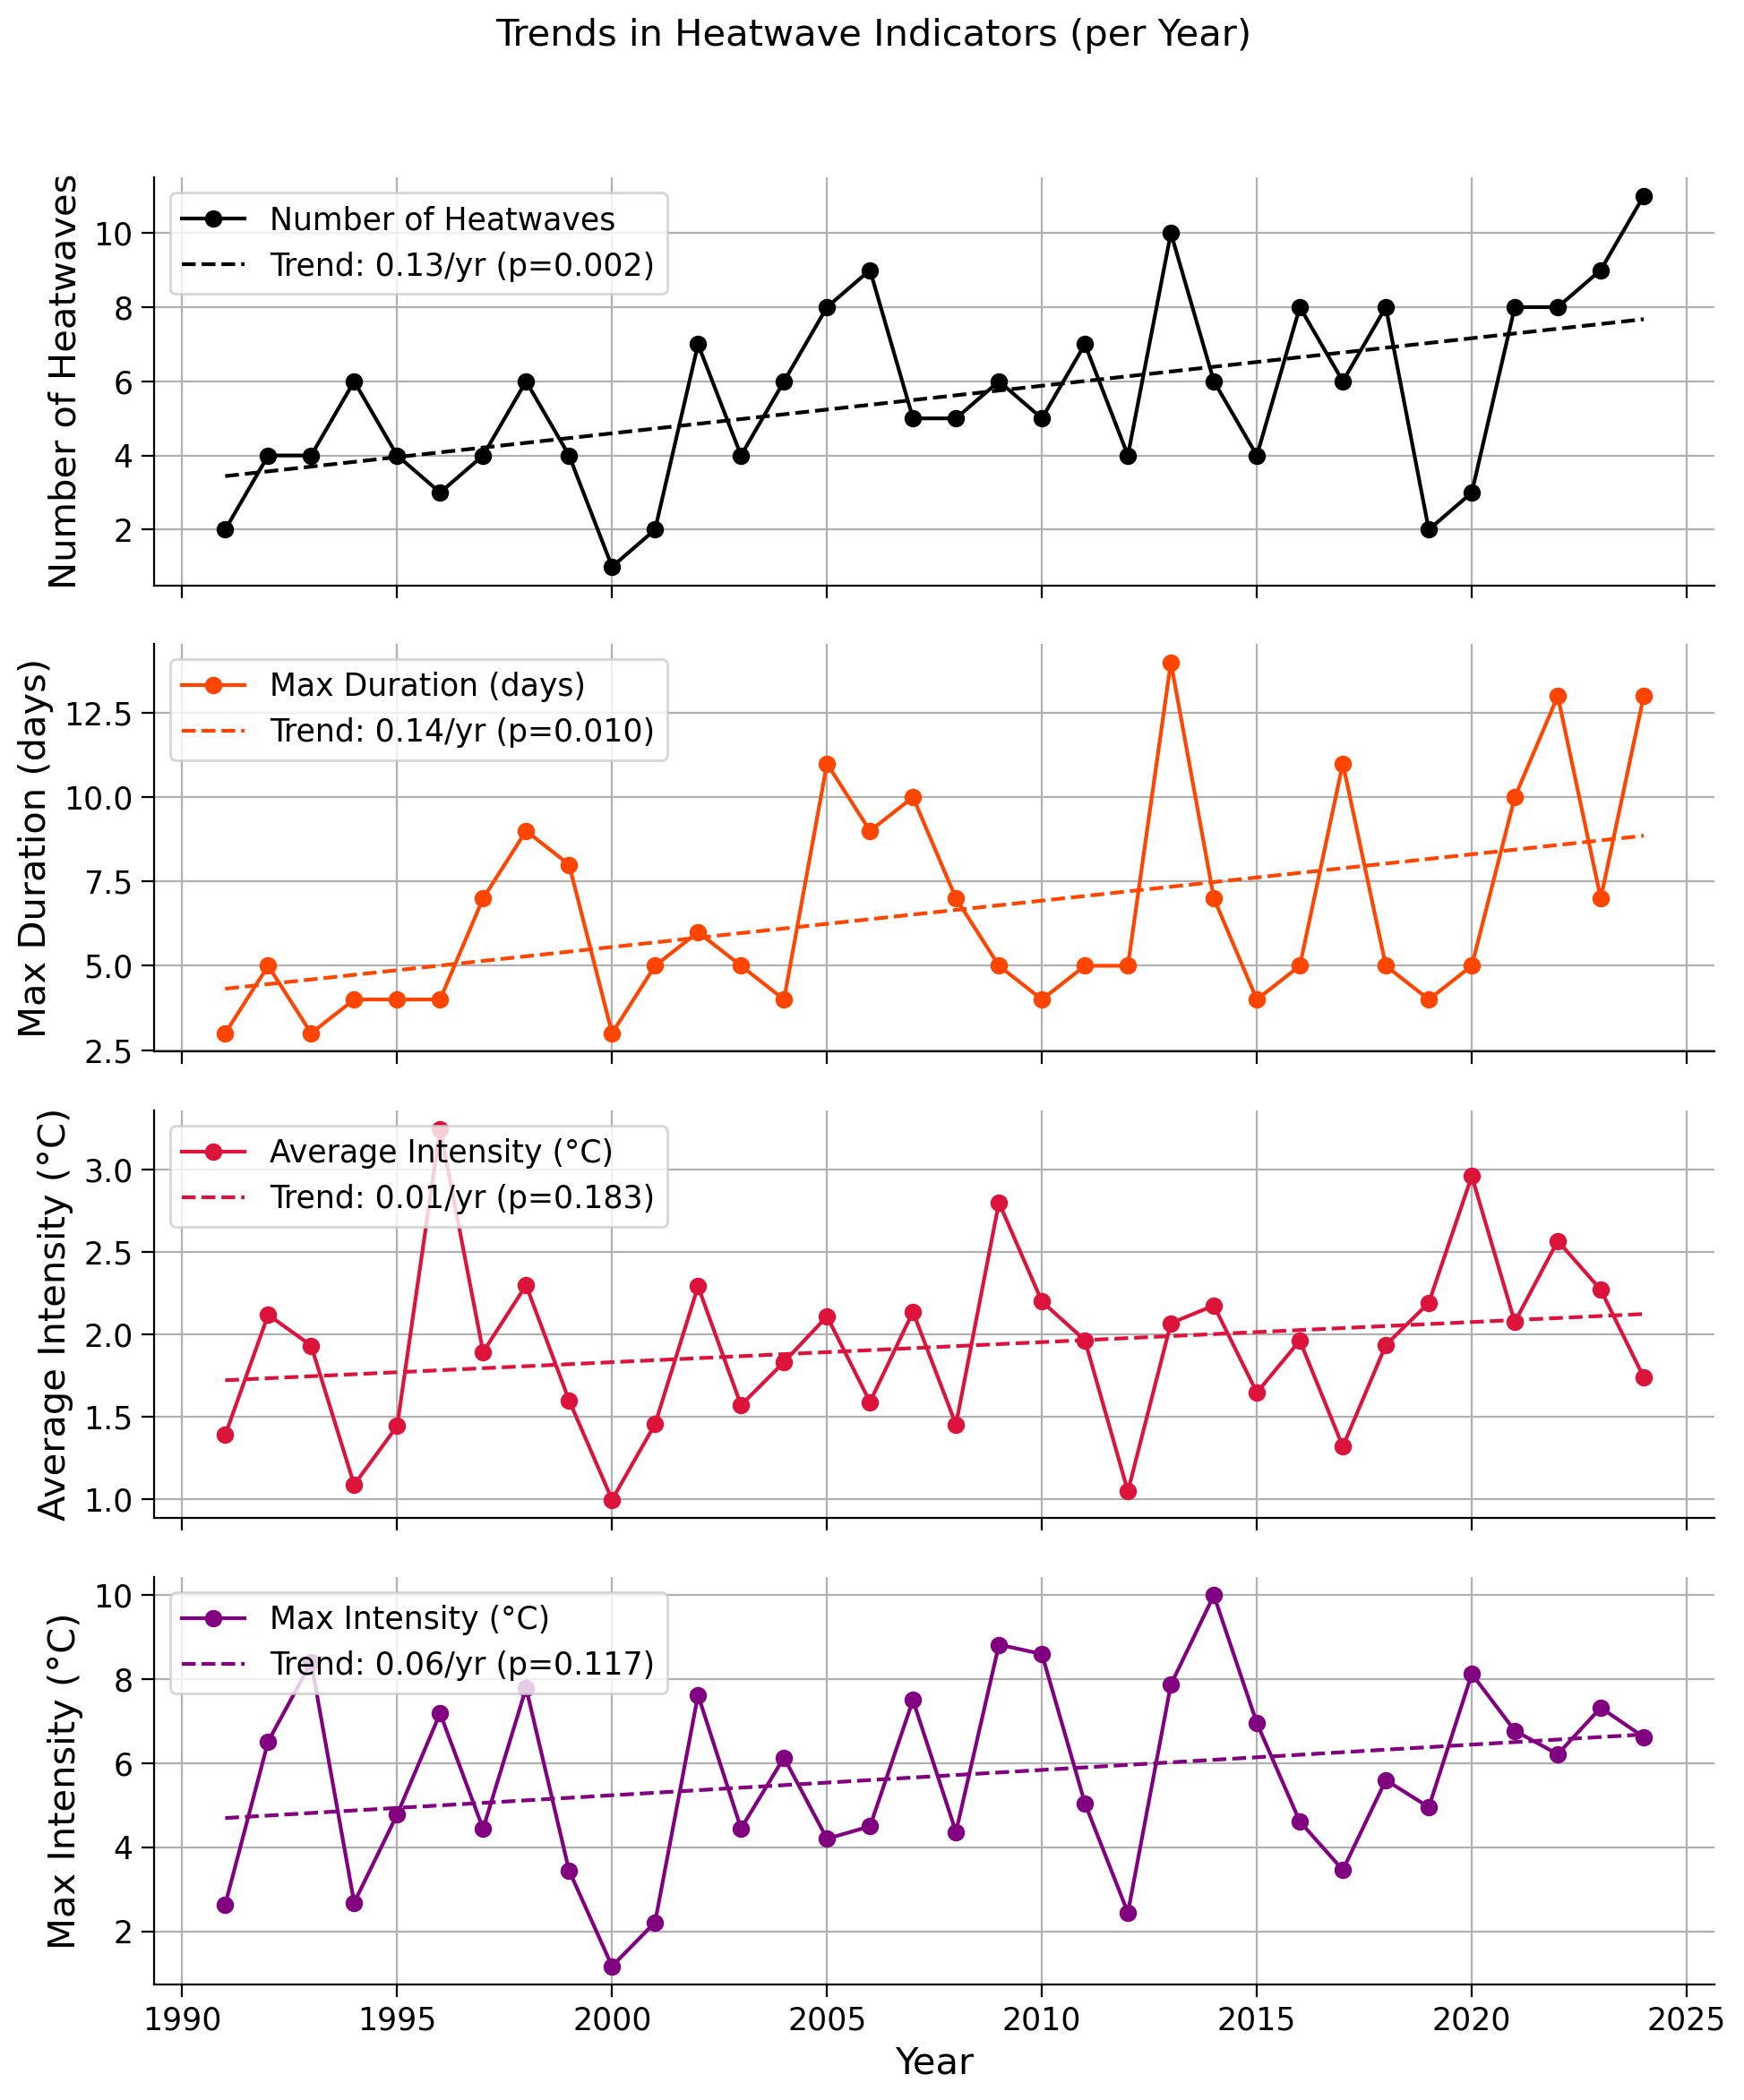

In [54]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

# Variables à tracer
variables = {
    'num_events': {'label': 'Number of Heatwaves', 'color': 'black'},
    'max_duration': {'label': 'Max Duration (days)', 'color': 'orangered'},
    'avg_intensity': {'label': 'Average Intensity (°C)', 'color': 'crimson'},
    'max_intensity': {'label': 'Max Intensity (°C)', 'color': 'purple'},
}

# Créer les subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 12), sharex=True)

x = df_stats['year']

for i, (var, props) in enumerate(variables.items()):
    y = df_stats[var]
    
    # Tracer les points
    axes[i].plot(x, y, 'o-', color=props['color'], label=props['label'])

    # Droite de tendance
    slope, intercept, r, p, _ = linregress(x, y)
    trend = intercept + slope * x
    axes[i].plot(x, trend, '--', color=props['color'],
                 label=f"Trend: {slope:.2f}/yr (p={p:.3f})")

    # Mise en forme
    axes[i].set_ylabel(props['label'])
    axes[i].grid(True)
    axes[i].legend(loc='upper left')

# Titre global et label X commun
axes[-1].set_xlabel("Year")
plt.suptitle("Trends in Heatwave Indicators (per Year)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


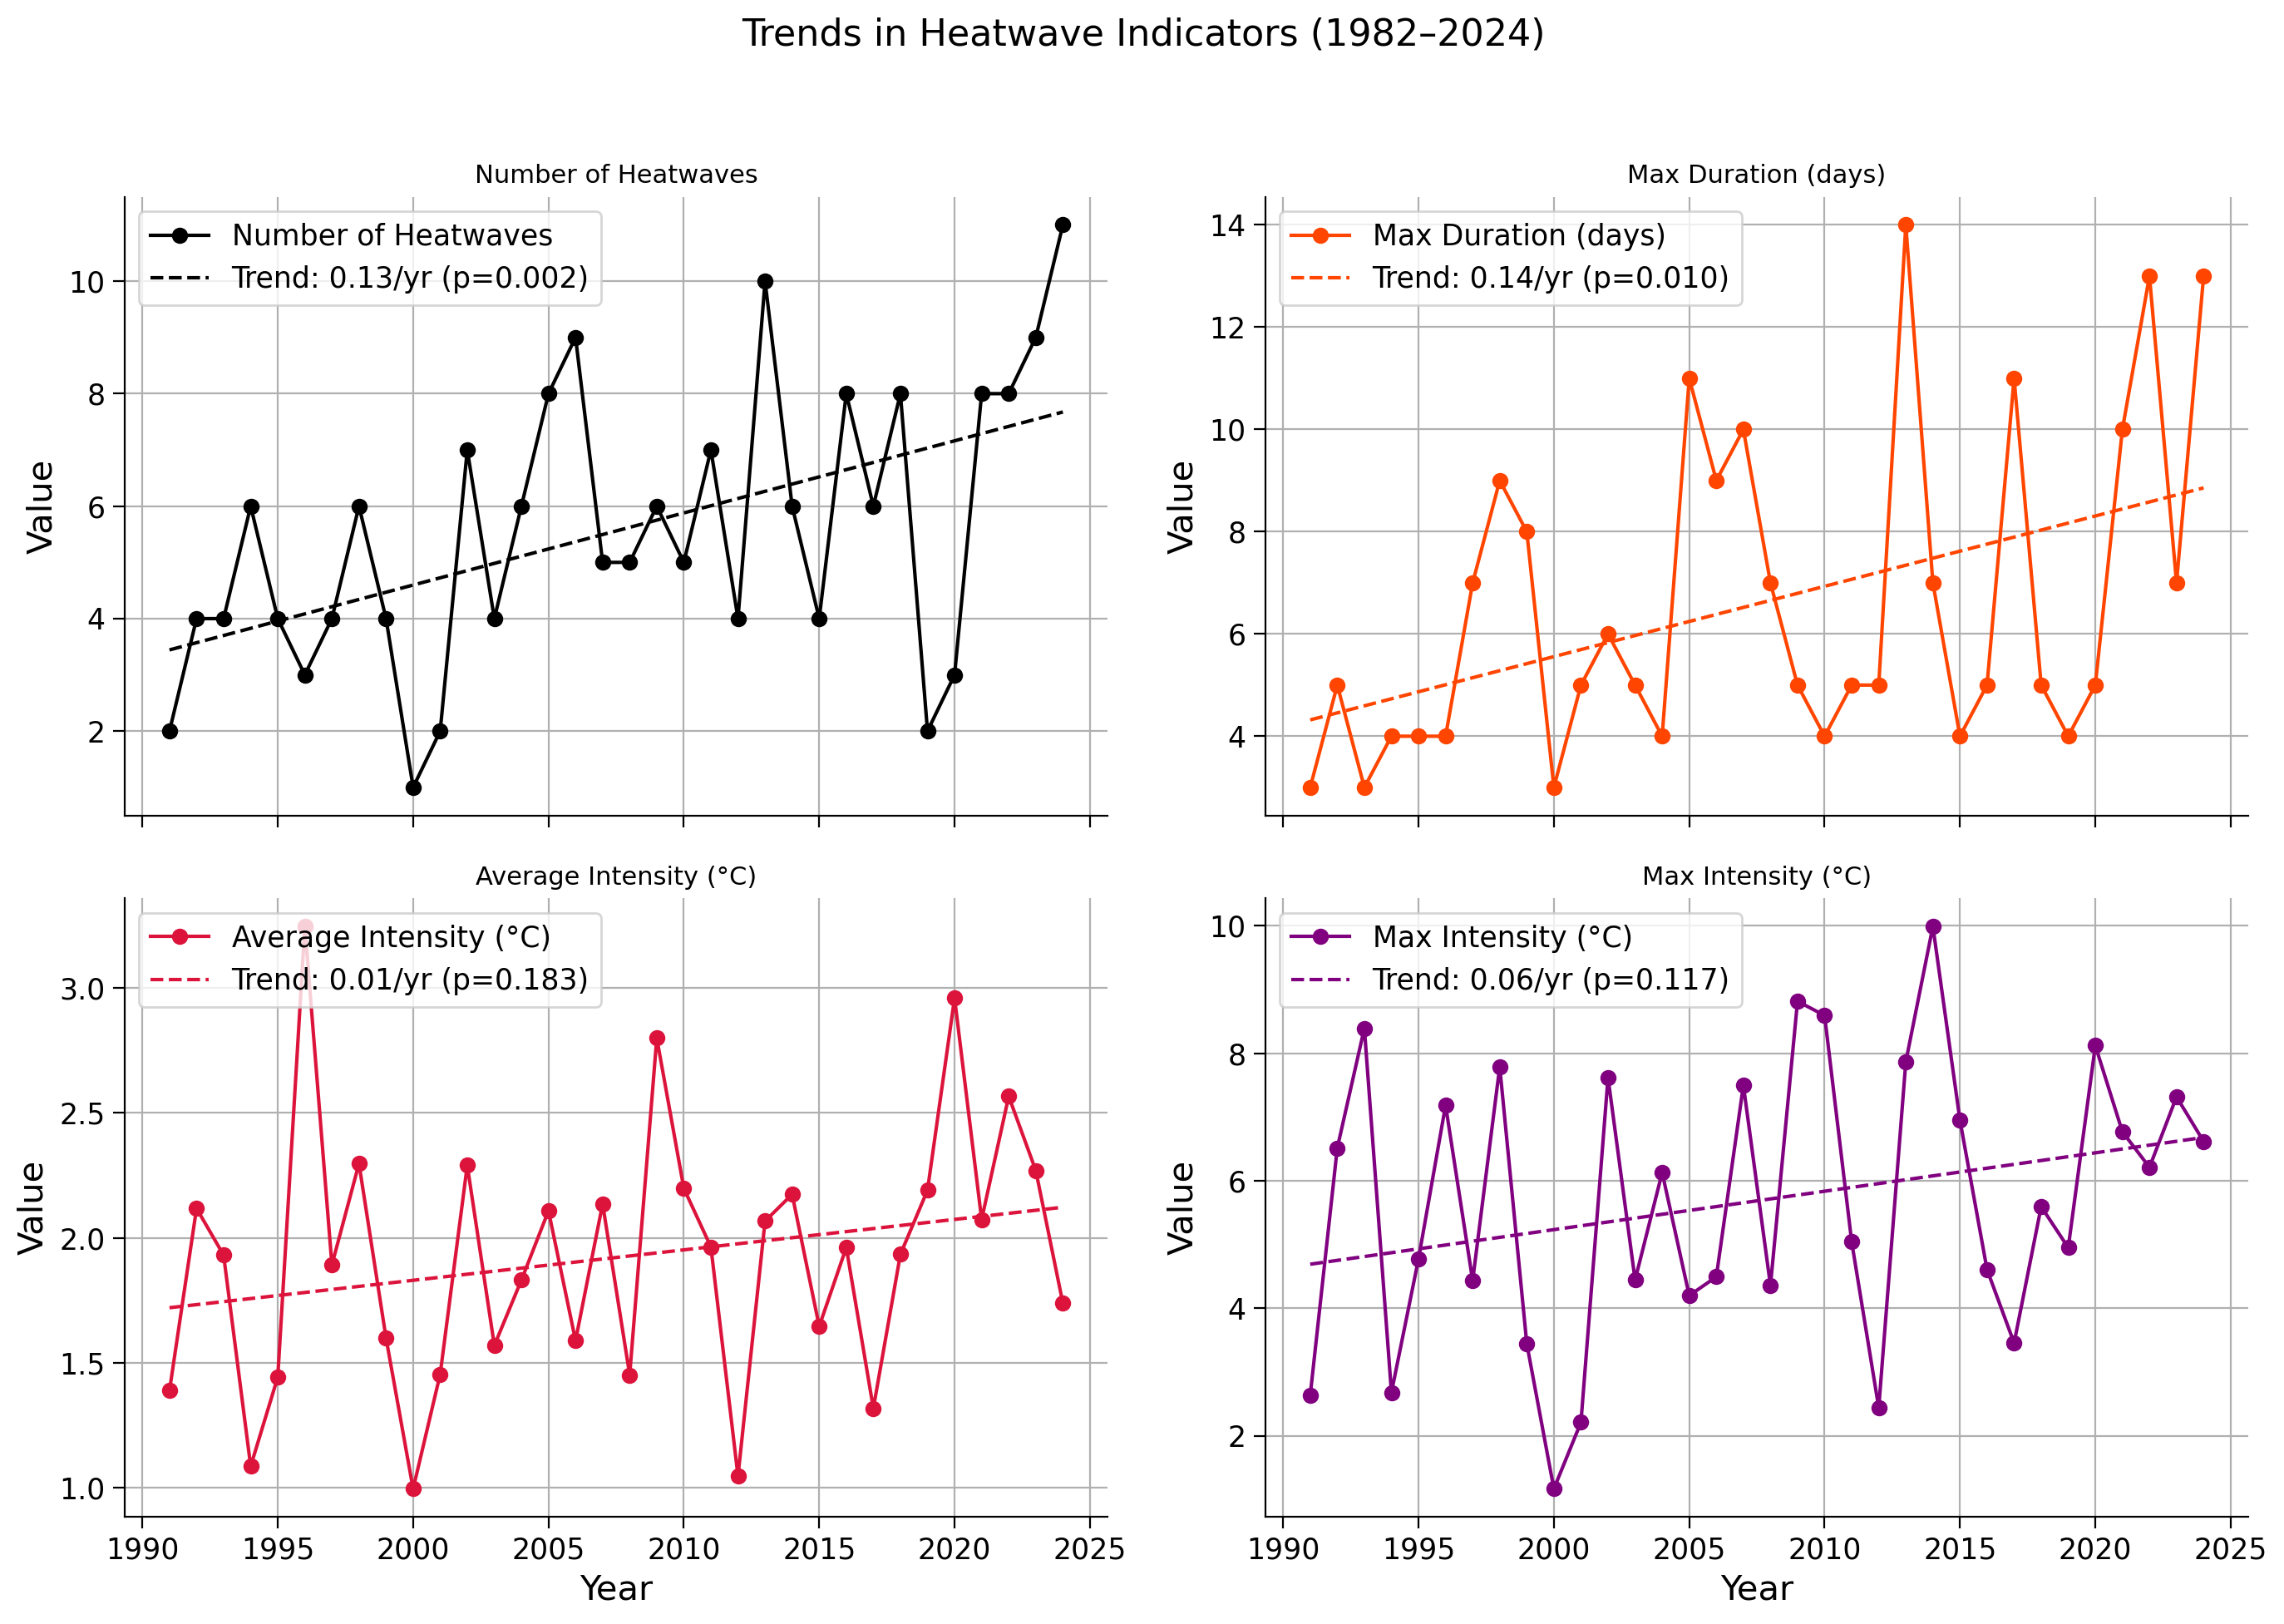

In [55]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

# Variables à tracer
variables = {
    'num_events': {'label': 'Number of Heatwaves', 'color': 'black'},
    'max_duration': {'label': 'Max Duration (days)', 'color': 'orangered'},
    'avg_intensity': {'label': 'Average Intensity (°C)', 'color': 'crimson'},
    'max_intensity': {'label': 'Max Intensity (°C)', 'color': 'purple'},
}

x = df_stats['year']

# Initialisation des subplots : 2 lignes, 2 colonnes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10), sharex=True)
axes = axes.flatten()  # Pour itérer facilement sur les axes

for i, (var, props) in enumerate(variables.items()):
    y = df_stats[var]
    
    # Tracer la série
    axes[i].plot(x, y, 'o-', color=props['color'], label=props['label'])

    # Droite de tendance
    slope, intercept, r, p, _ = linregress(x, y)
    trend = intercept + slope * x
    axes[i].plot(x, trend, '--', color=props['color'],
                 label=f"Trend: {slope:.2f}/yr (p={p:.3f})")

    # Mise en forme
    axes[i].set_title(props['label'], fontsize=11)
    axes[i].set_ylabel("Value")
    axes[i].grid(True)
    axes[i].legend(loc='upper left')

# Ajouter le label X uniquement aux graphiques du bas
axes[2].set_xlabel("Year")
axes[3].set_xlabel("Year")

# Titre général
plt.suptitle("Trends in Heatwave Indicators (1982–2024)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [56]:
print("Top 5 years with highest values for each heatwave indicator:\n")

for var in ['num_events', 'max_duration', 'avg_intensity', 'max_intensity']:
    print(f"→ {var}:")
    top5 = df_stats.sort_values(by=var, ascending=False).head(5)[['year', var]]
    for _, row in top5.iterrows():
        print(f"   - {int(row['year'])}: {row[var]:.2f}")
    print()



Top 5 years with highest values for each heatwave indicator:

→ num_events:
   - 2024: 11.00
   - 2013: 10.00
   - 2006: 9.00
   - 2023: 9.00
   - 2021: 8.00

→ max_duration:
   - 2013: 14.00
   - 2024: 13.00
   - 2022: 13.00
   - 2005: 11.00
   - 2017: 11.00

→ avg_intensity:
   - 1996: 3.24
   - 2020: 2.96
   - 2009: 2.80
   - 2022: 2.57
   - 1998: 2.30

→ max_intensity:
   - 2014: 9.99
   - 2009: 8.82
   - 2010: 8.59
   - 1993: 8.39
   - 2020: 8.12

